In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### 1. Load Dataset (~20,000+ rows)

In [83]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [84]:
df.shape

(20640, 9)

In [85]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [86]:
print("\n--- Feature Skewness Values ---")
skewness = df.skew().sort_values(ascending=False)
print(skewness)


--- Feature Skewness Values ---
AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801
dtype: float64


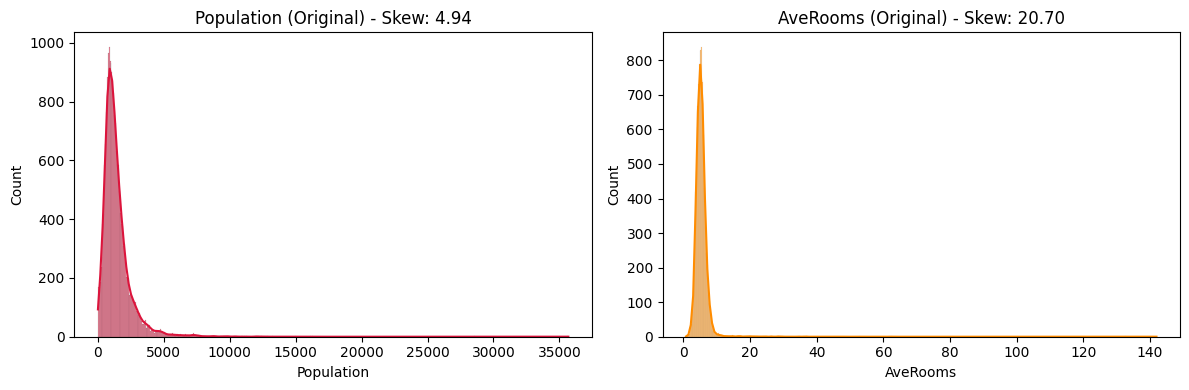

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Population"], kde=True, ax=axes[0], color='crimson')
axes[0].set_title(f"Population (Original) - Skew: {df['Population'].skew():.2f}")

sns.histplot(df['AveRooms'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f"AveRooms (Original) - Skew: {df['AveRooms'].skew():.2f}")

plt.tight_layout()
plt.show()

In [88]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [89]:
skew_mask = X.skew().sort_values(ascending=False) > 1
skewed_features = skew_mask[skew_mask].index.tolist()
skewed_features

['AveOccup', 'AveBedrms', 'AveRooms', 'Population', 'MedInc']

In [90]:
skew_mask = X.skew().sort_values(ascending=False) < 1
normal_features = skew_mask[skew_mask].index.tolist()
normal_features

['Latitude', 'HouseAge', 'Longitude']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
skewed_transformer = Pipeline([
    ("power_transform", PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

In [93]:
normal_transformer = Pipeline([
    ('scaler', StandardScaler())
])

In [94]:
preprocessor = ColumnTransformer(
    [
        ("skewed", skewed_transformer, skewed_features),
        ("normal", normal_transformer, normal_features),
    ]
)

In [101]:
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

In [102]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed',
                                                  Pipeline(steps=[('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AveOccup', 'AveBedrms',
                                                   'AveRooms', 'Population',
                                                   'MedInc']),
                                                 ('normal',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'HouseAge',
                                                   'Longitude'])])),
                ('model', RandomForestRegressor())])

In [103]:
y_pred = full_pipeline.predict(X_test)

In [104]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [105]:
print("\n--- Model Evaluation Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")


--- Model Evaluation Performance ---
Mean Squared Error (MSE): 0.2528
R² Score: 0.8071


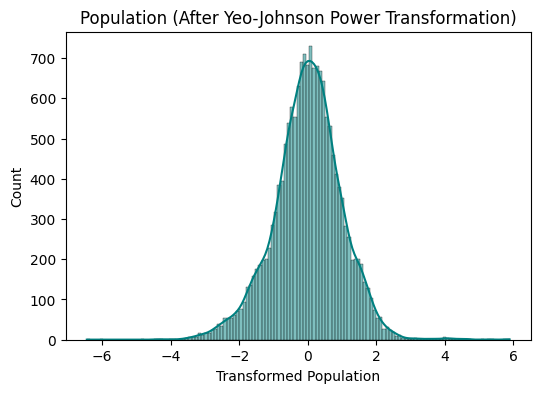

In [106]:
X_train_transformed = preprocessor.fit_transform(X_train)

# Extract transformed Population feature (it's the first column in transformed array)
transformed_pop = X_train_transformed[:, 0]

plt.figure(figsize=(6, 4))
sns.histplot(transformed_pop, kde=True, color='teal')
plt.title("Population (After Yeo-Johnson Power Transformation)")
plt.xlabel("Transformed Population")
plt.show()